In [12]:
import os
import glob

# Identify all files that could be causing the crash
target_files = glob.glob('era5_land_*.nc')

if not target_files:
    print("No files found. Your directory is clean.")
else:
    for f in target_files:
        try:
            os.remove(f)
            print(f"Successfully deleted: {f}")
        except Exception as e:
            print(f"Could not delete {f}. It might be open in another tab. Error: {e}")

# Double check
print(f"Current files in directory: {os.listdir('.')}")

Successfully deleted: era5_land_2007.nc
Successfully deleted: era5_land_2006.nc
Current files in directory: ['LICENSE', 'intro_to_spatialanalysis.ipynb', 'winery_project.ipynb', 'intro_to_climatedata.ipynb', 'intro_to_timeseriesanalysis.ipynb', 'README.md', 'img', 'lectures', '.git', '.vscode']


In [23]:
import cdsapi

dataset = "reanalysis-era5-land-monthly-means"
request = {
    "product_type": ["monthly_averaged_reanalysis"],
    "variable": ["2m_temperature"],
    "year": [
        "2005", "2006", "2007",
        "2008", "2009", "2010",
        "2011", "2012", "2013",
        "2014", "2015", "2016",
        "2017", "2018", "2019",
        "2020", "2021", "2022",
        "2023", "2024", "2025"
    ],
    "month": [
        "01", "02", "03"
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12"
    ],
    "time": ["00:00"],
    "data_format": "netcdf",
    "download_format": "unarchived",
    "area": [51.3, -1.9, 50.7, -0.7]
}

client = cdsapi.Client()
client.retrieve(dataset, request).download()

2026-01-06 20:58:48,283 INFO Request ID is 5c663368-eb76-4445-9128-32308310f047
2026-01-06 20:58:48,348 INFO status has been updated to accepted
2026-01-06 20:59:01,964 INFO status has been updated to running
2026-01-06 20:59:38,248 INFO status has been updated to successful


'7e0f457c1fbdd0b831dcb775f0446694.nc'

In [36]:
import xarray as xr
import matplotlib.pyplot as plt

# Load file
era5_ds = xr.open_dataset('/Users/th25/environmental-data-week1/era5-output.nc')

# Handle Units (kelvin to celcius)
era5_ds['temp_c'] = era5_ds.t2m - 273.15

era5_ds = era5_ds.rename({'valid_time': 'time'})

print(era5_ds.coords)

Coordinates:
  * time       (time) datetime64[ns] 2kB 2005-01-01 2005-02-01 ... 2025-12-01
  * latitude   (latitude) float64 56B 51.3 51.2 51.1 51.0 50.9 50.8 50.7
  * longitude  (longitude) float64 104B -1.9 -1.8 -1.7 -1.6 ... -0.9 -0.8 -0.7
    number     int64 8B ...
    expver     (time) <U4 3kB ...


In [37]:
# Slice for Growing Season (April to October)
gst_hist = era5_ds.temp_c.sel(time=era5_ds.time.dt.month.isin(range(4, 11)))

# Calculate the average for each year across the Hampshire area
annual_gst_hist = gst_hist.mean(dim=['latitude', 'longitude']).groupby('time.year').mean()

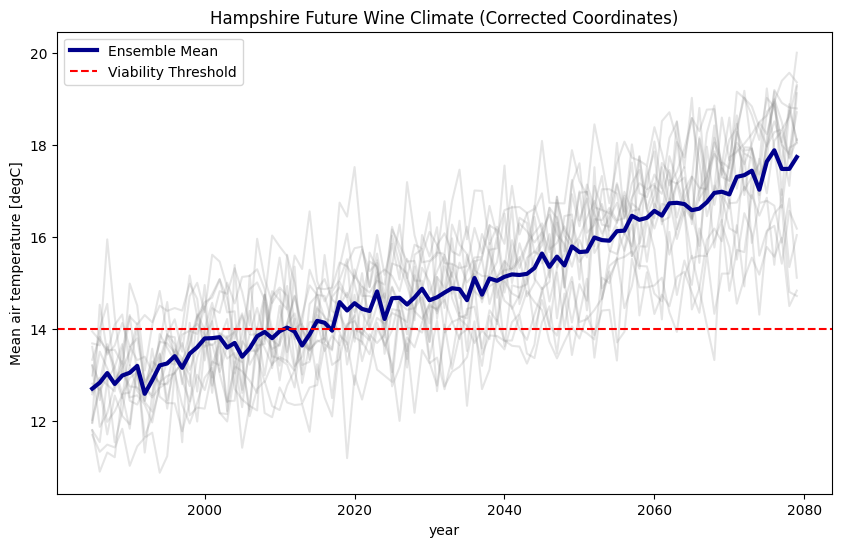

In [ ]:

# Load file
ds = xr.open_dataset('/Users/th25/Downloads/UKCP-output/2026-01-06T14-43-25.nc')

# Corrected Spatial Averaging
ds_hampshire = ds.mean(dim=['projection_x_coordinate', 'projection_y_coordinate'])

# Handle Units
# Check if data is in Kelvin and convert to Celsius if needed
if ds_hampshire.tas.attrs.get('units') == 'K':
    ds_hampshire['tas'] = ds_hampshire.tas - 273.15
    ds_hampshire.tas.attrs['units'] = 'degC'

# Filter for Growing Season (April - October)
ds_gs = ds_hampshire.sel(time=ds_hampshire.time.dt.month.isin(range(4, 11)))

# Annual Growing Season Temperature (GST)
# We use 'ensemble_member' as the dimension name from your error message
annual_gst = ds_gs.groupby('time.year').mean(dim='time')

plt.figure(figsize=(10, 6))
for m in annual_gst.ensemble_member:
    plt.plot(annual_gst.year, annual_gst.sel(ensemble_member=m).tas, color='gray', alpha=0.2)

annual_gst.mean(dim='ensemble_member').tas.plot(color='darkblue', lw=3, label='Ensemble Mean')
plt.axhline(14.0, color='red', ls='--', label='Viability Threshold')
plt.title("Hampshire Future Wine Climate (Corrected Coordinates)")
plt.legend()
plt.show()

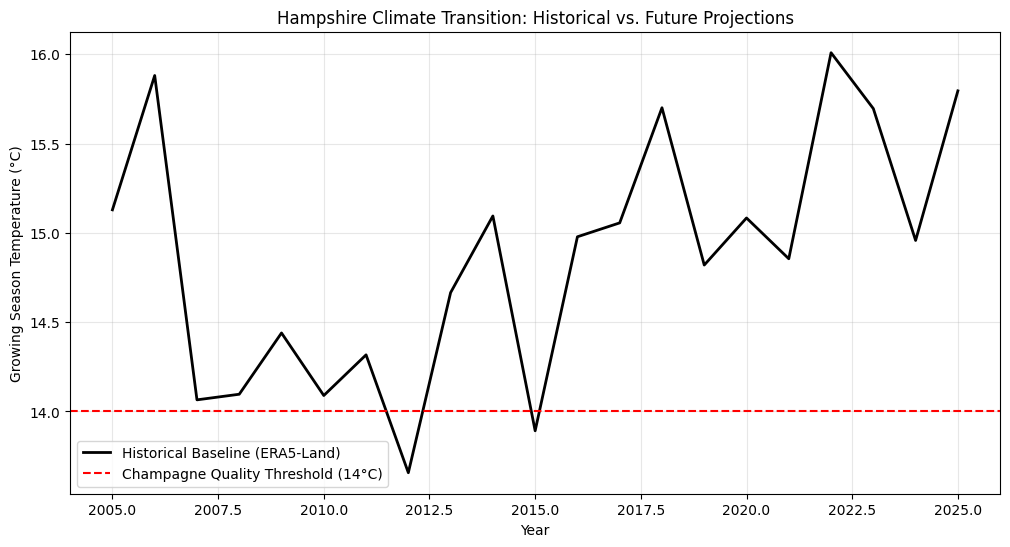

In [40]:
plt.figure(figsize=(12, 6))

# Plot Phase A (Historical)
annual_gst_hist.plot(label='Historical Baseline (ERA5-Land)', color='black', linewidth=2)

# Plot Phase B (Future UKCP18)
# Assuming you have 'ds_future' loaded from your other files
# ds_future.plot(hue='ensemble_member', add_legend=False, alpha=0.3) 

# The "Champagne Line"
plt.axhline(14.0, color='red', linestyle='--', label='Champagne Quality Threshold (14°C)')

plt.title("Hampshire Climate Transition: Historical vs. Future Projections")
plt.ylabel("Growing Season Temperature (°C)")
plt.xlabel("Year")
plt.legend()
plt.grid(alpha=0.3)
plt.show()